In [ ]:
Only run this for testing. Real one is below

In [ ]:
import pandas as pd

df = pd.read_json("../Data/Biohackers_submissions.jsonl", lines=True)

In [2]:
import pandas as pd
from networkx.classes import non_neighbors
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import logging
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from bertopic.vectorizers import OnlineCountVectorizer

In [8]:
# Setup logging
logging.basicConfig(format="%(asctime)s — %(levelname)s — %(message)s", level=logging.INFO)
logger = logging.getLogger(__name__)

In [4]:
def process_docs(chunk):
    chunk = chunk[['title', 'selftext']].fillna('')
    return (chunk['title'] + ' ' + chunk['selftext']).tolist()

In [ ]:
def run_topic_modeling_partial(path, chunk_size=100_000, min_topic_size=10):
    reader = pd.read_json(path, lines=True, chunksize=chunk_size)
    #embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embedding_model = SentenceTransformer("flax-sentence-embeddings/reddit_single-context_mpnet-base")

    # Increase dimensions to capture more variance
    umap_model = IncrementalPCA(n_components=15)

    # Increase number of clusters and reduce min_cluster_size
    cluster_model = MiniBatchKMeans(n_clusters=100,
                                    batch_size=1000,
                                    random_state=42)

    # Adjust vectorizer parameters to capture more distinct terms
    vectorizer_model = OnlineCountVectorizer(stop_words="english",
                                             decay=0.005,  # Slower decay rate
                                             min_df=1,  # Include rarer terms
                                             ngram_range=(1, 2))  # Include bigrams

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        nr_topics=20,  # Set explicit number instead of "auto"
        min_topic_size=min_topic_size,  # Allow smaller topic clusters
        calculate_probabilities=True,
        verbose=True,
    )

    all_docs = []
    all_topics = []

    for i, chunk in enumerate(reader):
        docs = process_docs(chunk)
        all_docs.extend(docs)
        logger.info(f"Chunk {i + 1}, docs: {len(docs)}")

        if i == 0:
            topic_model.fit(docs)
            logger.info("Initial fit() on chunk 1")
        else:
            topic_model.partial_fit(docs)
            logger.info(f"partial_fit() on chunk {i + 1}")
        all_topics.extend(topic_model.topics_)

    topic_model.topics_ = all_topics
    pd.DataFrame(all_topics).to_csv("all_topics.csv", index=False)
    return topic_model

In [ ]:
path = "/Users/marcelldanka/TDK/Echoes-of-Longevity-Research/SocialMedia/Reddit/Data/merged_submissions.jsonl"
topic_model = run_topic_modeling_partial(path, chunk_size=100_000)

# Get topic info
topic_info = topic_model.get_topic_info()
topic_info.to_csv('./TopicModelling_merged_reddit_embedding_model.csv', index=False)

2025-07-22 16:42:34,189 — INFO — Sampling documents across chunks
2025-07-22 16:43:12,239 — INFO — Loaded 1390597 documents (full dataset)
2025-07-22 16:43:12,240 — INFO — Loaded sample size: 1390597
2025-07-22 16:43:12,352 — INFO — Use pytorch device_name: mps
2025-07-22 16:43:12,352 — INFO — Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2025-07-22 16:43:15,439 — INFO — Fitting topic model
2025-07-22 16:43:15,721 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/43457 [00:00<?, ?it/s]

In [ ]:
for col in df.columns:
    print(col)

In [ ]:
print(df.shape)
print(df.info())
print(df.describe(include='all'))

(1390597, 135)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1390597 entries, 0 to 1390596
Columns: 135 entries, archived to year
dtypes: bool(2), datetime64[ns, UTC](1), float64(68), int32(1), int64(3), object(60)
memory usage: 1.4+ GB
None


In [ ]:
Missing values by column

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

year
2008      7951
2009     25126
2010     25763
2011     29626
2012     68243
2013     84096
2014     75806
2015     92896
2016    140951
2017    123114
2018    141604
2019    110349
2020    118498
2021     92736
2022     78787
2023     81077
2024     93974
Name: count, dtype: int64


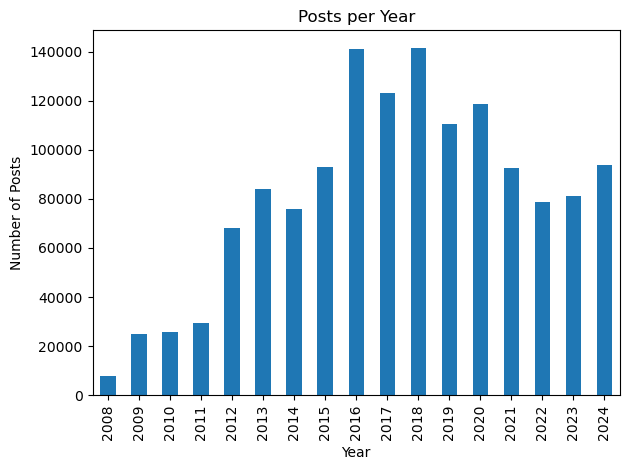

In [8]:
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', utc=True)
df['year'] = df['created_utc'].dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)
year_counts = df.groupby(df['created_utc'].dt.year).size()

import matplotlib.pyplot as plt

year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.title('Posts per Year')
plt.tight_layout()
plt.show()

In [ ]:
Topic modelling

In [ ]:
import logging

# Setup basic logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

In [ ]:
import pandas as pd

sample_df = df.sample(n=500, random_state=42).fillna({"title": "", "selftext": ""})
docs = (sample_df['title'] + " " + sample_df['selftext']).tolist()
logger.info(f"Prepared {len(docs)} documents for topic modeling")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

logger.info("Loading embedding model")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

logger.info("Initializing vectorizer and BERTopic")
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    max_features=3000
)
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True  # Enables BERTopic’s built-in progress logging  [oai_citation:2‡Stack Overflow](https://stackoverflow.com/questions/76856592/jupyter-keeps-crashing-when-using-bertopics-fit-transform?utm_source=chatgpt.com)
)

In [ ]:
logger.info("Starting fit_transform() on sample documents")
topics, probs = topic_model.fit_transform(docs)
logger.info("Completed BERTopic modeling")

logger.info("Retrieving and displaying topic info")
topic_info = topic_model.get_topic_info()
topic_info.head()

In [ ]:
try:
    logger.info("Generating interactive topic visualization")
    fig = topic_model.visualize_topics()
    fig.write_html("sample_topic_vis.html")
    logger.info("Saved visualization to sample_topic_vis.html")
except Exception as e:
    logger.error(f"Visualization failed: {e}")